**Importing libraries**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt
from IPython.display import display

**Uploading the dataset**

In [2]:
from google.colab import files
data_frame = files.upload()

Saving Dataset on CCPP.xlsx to Dataset on CCPP.xlsx


**Description about Dataset**

In [3]:
dataset = pd.read_excel('Dataset on CCPP.xlsx')
print(dataset.columns)
print(dataset.shape)
print("Null Values Check:")
print(dataset.isnull().sum())
print(dataset.head(30))

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')
(9568, 5)
Null Values Check:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
       AT      V       AP      RH      PE
0    9.44  40.00  1015.62   81.16  471.32
1   23.49  49.30  1003.35   77.96  442.76
2    4.99  39.04  1020.45   78.89  472.52
3   18.24  58.46  1017.38   86.92  449.63
4   27.49  63.78  1015.43   47.45  445.66
5   13.61  41.16  1020.49   75.09  462.67
6   29.75  73.50  1011.13   67.31  433.63
7   27.38  77.24  1008.25   82.49  435.81
8   18.28  60.10  1009.72   85.79  452.93
9   23.74  62.96  1019.65   63.39  449.48
10   7.78  40.80  1026.70   85.61  488.54
11  19.72  46.21  1010.54   77.74  449.33
12  23.18  72.99  1009.01   90.09  439.12
13  18.50  52.08  1006.23  100.09  451.23
14  14.39  42.77  1017.36   83.28  463.65
15  29.56  52.84  1006.09   42.17  436.46
16   8.40  38.50  1013.67   69.13  486.50
17  25.47  60.75  1007.27   65.91  438.42
18  15.23  44.90  1007.75   81.34  456.07
19  12.78  44.60  1013.64

**Splitting the dataset into the Training set and Test set**

In [4]:
from sklearn.model_selection import train_test_split

x = dataset[['AT', 'V', 'AP', 'RH', 'PE']]
y = dataset['PE']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

**Standardize the input features**

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Train a Random Forest Regressor**

In [6]:
rf = RandomForestRegressor(max_depth=15, n_estimators=50, random_state=42)
rf.fit(x_train_scaled, y_train)

RandomForestRegressor(max_depth=15, n_estimators=50, random_state=42)

**Display the model's performance**

In [7]:
tran_score = rf.score(x_train_scaled, y_train)
test_score = rf.score(x_test_scaled, y_test)
print(f"Training Score: {tran_score: .4f}")
print(f"Testing Score: {test_score: .4f}")

Training Score:  1.0000
Testing Score:  1.0000


*We use TreeExplainer as it is optimized for tree based models like Random Forest*

In [8]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test_scaled)

**Generate summary plot**

The summary plot is: 


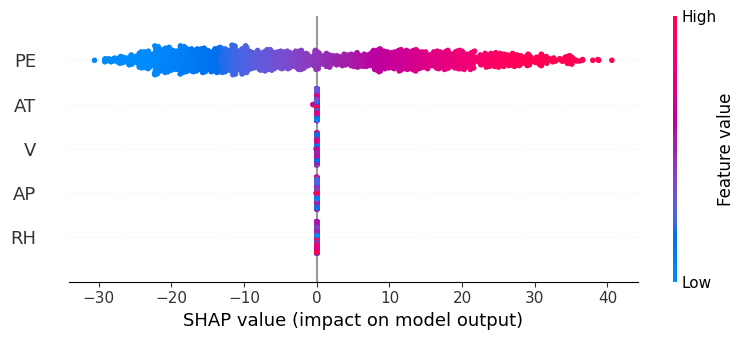

<Figure size 640x480 with 0 Axes>

In [9]:
print("The summary plot is: ")
shap.summary_plot(shap_values, x_test_scaled, feature_names= x.columns.tolist())
plt.savefig("summary_plot.png")

**Generate individual force plot for a specific instance**

In [12]:
instance_index = 15
instance = x_test.iloc[[instance_index]]
instance_scaled = scaler.transform(instance)
shap_value_instance = explainer.shap_values(instance_scaled)

print(f"Generating force plot for instance index {instance_index}...")
force_plot = shap.force_plot(explainer.expected_value[0], shap_value_instance[0], instance_scaled[0], feature_names=x.columns.tolist())
plt.savefig("force_plot.png")

Generating force plot for instance index 15...


<Figure size 640x480 with 0 Axes>

**Display the force plot**

In [13]:
shap.initjs()
display(force_plot)

**Global Interpretability: Detailed Plots**
*SHAP Summary Plot*

Generating detailed SHAP plot...


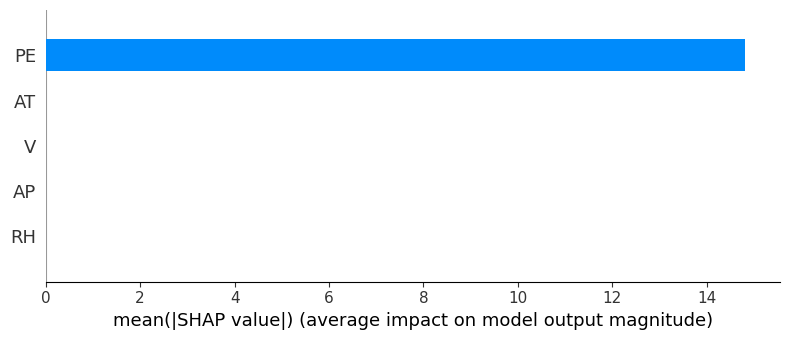

<Figure size 640x480 with 0 Axes>

In [14]:
print("Generating detailed SHAP plot...")
shap.summary_plot(shap_values, x_test_scaled, feature_names=x.columns.tolist(), plot_type = 'bar')
plt.savefig("detailed_shap_plot.png")

**SHAP Dependence Plot for each feature**

Generating SHAP dependence plot for feature 'AT'...


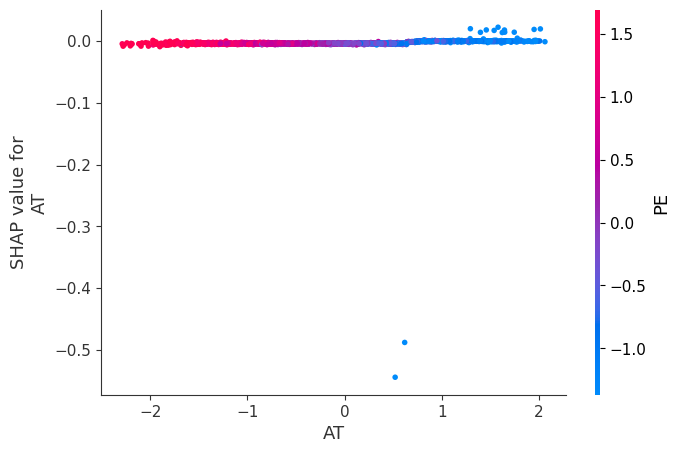

Generating SHAP dependence plot for feature 'V'...


<Figure size 640x480 with 0 Axes>

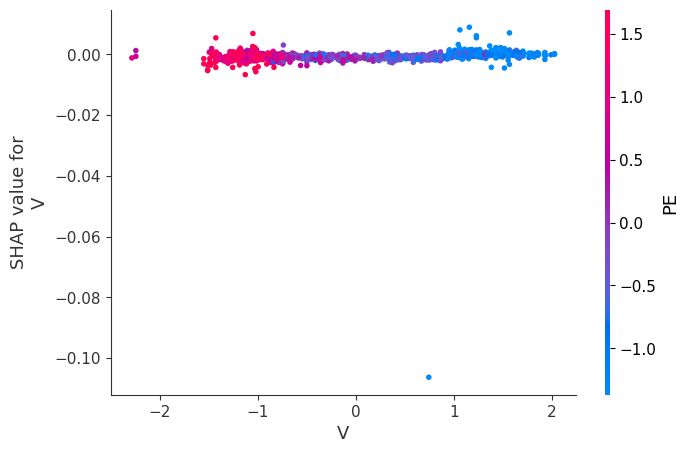

Generating SHAP dependence plot for feature 'AP'...


<Figure size 640x480 with 0 Axes>

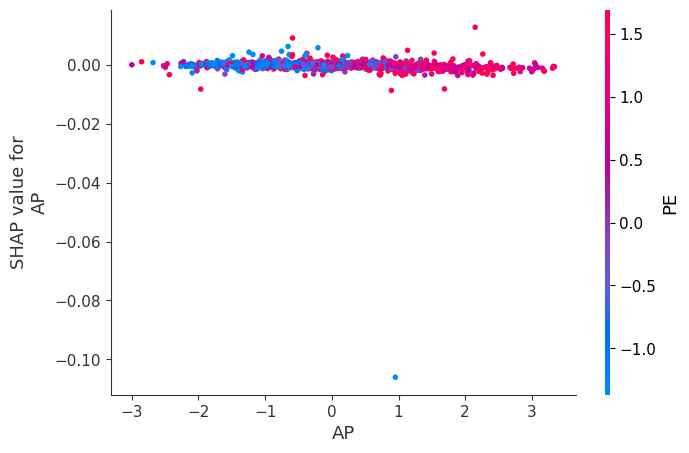

Generating SHAP dependence plot for feature 'RH'...


<Figure size 640x480 with 0 Axes>

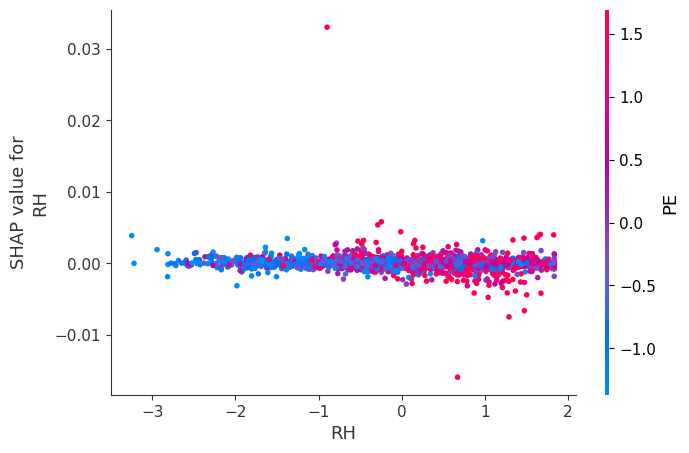

Generating SHAP dependence plot for feature 'PE'...


<Figure size 640x480 with 0 Axes>

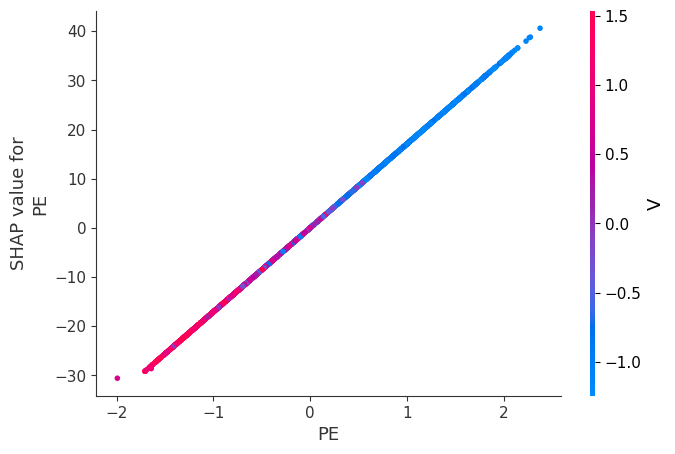

<Figure size 640x480 with 0 Axes>

In [18]:
for feature in x.columns:
  print(f"Generating SHAP dependence plot for feature '{feature}'...")
  shap.dependence_plot(feature, shap_values, x_test_scaled, feature_names=x.columns.tolist())
  plt.savefig(f"{feature}_dependence_plot.png")

# Improving performance of a Combined Cycle Power Plant (CCP)using Explainable AI
**Key Actionable Inferences derived from using Explainable AI through Shapley Values**

*   Increase in Ambient Air temperature (AT) decreases the performance a Power Plant.Their is inverse relationship between the both.
*   Increase in Relative Humidity of air (RH) decreases the performance a Power Plant.Their is inverse relationship between the both.
*   Increase in vacuum pressure (VP) decreases the performance a Power Plant.Their is inverse relationship between the both.The vacuum pressure is the pressure maintained inside the condenser by the vacuum pump, which condenses the steam from the steam turbine back into water for reuse.









